In [62]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.ticker import FuncFormatter
import sklearn
import sys
import statsmodels.api as sm
from scipy.stats.mstats import gmean

import statsmodels.formula.api as smf
import warnings
#from pingouin import ancova

from datetime import datetime, timedelta,date
import datetime as dt     
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
# These are used for the chi-squared test and post hoc testing
from scipy.stats import chi2_contingency
# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 100

In [63]:
# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

In [64]:
current_date = pd.to_datetime('today').date().strftime("%Y-%m-%d")


In [65]:
# File updated on Oct 2 2023 in order to deal with erroneous zeroes in the cbc data
subjects = pd.read_csv("data/aim2_exwas_data_2024-June-11.csv")
subjects = subjects[subjects['EBF_6m']==0]

dust_dehp_upper_quartile = subjects['log_dehp_bc_rec_dust_3m'].quantile(0.75)
for index, row in subjects.iterrows():

    if str(row['log_dehp_bc_rec_dust_3m'])!='nan':
        if row['log_dehp_bc_rec_dust_3m']>dust_dehp_upper_quartile:
            subjects.loc[index,"high_dehp_dust_3m"]=1
        else:
            subjects.loc[index,"high_dehp_dust_3m"]=0


subjects = subjects.replace([np.inf, -np.inf], np.nan)

subjects.rename(columns={'log_C22:4n6_3m':'adrenic_acid'}, inplace=True)

adrenic_acid_upper_quartile = subjects['adrenic_acid'].quantile(0.75)

for index, row in subjects.iterrows():
    if str(row['adrenic_acid'])!='nan':
        if row['adrenic_acid']>adrenic_acid_upper_quartile:
            subjects.loc[index,"adrenic_acid_upper_quartile"]=1
        else:
            subjects.loc[index,"adrenic_acid_upper_quartile"]=0




In [66]:
vitamin_d_use_df = pd.read_csv("data/vitamin_D_use_by_infant_all_sources_3m.csv")
subjects = subjects.merge(vitamin_d_use_df, on="subject_id", how="left")

<Axes: xlabel='log_dehp_bc_rec_dust_3m', ylabel='Count'>

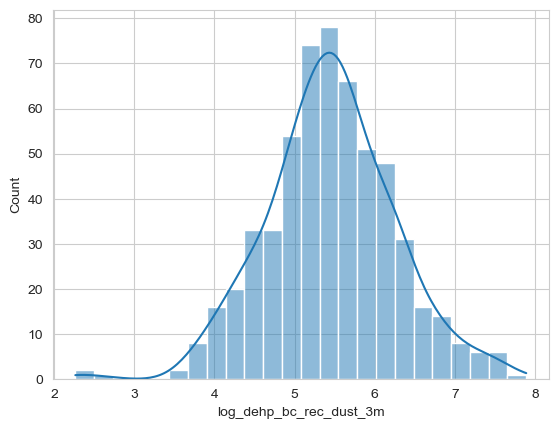

In [67]:
sns.histplot(data=subjects,x='log_dehp_bc_rec_dust_3m',kde=True)

# Read in CBC data, calculate ratios and log transform

In [68]:
child_absolute_cbc = pd.read_csv("data/wbc-absolute-value-1y-and-5y-variables-wide.csv")
child_absolute_cbc_metadata = pd.read_csv("metadata/wbc-absolute-value-1y-and-5y-metadata.csv")
xref_to_short_name={}
for index, row in child_absolute_cbc_metadata.iterrows():
    suffix=""  

   
    if row['visit'] == 'Birth':
        suffix="birth"
    if row['visit'] == '1 Year':
        suffix="1Y"
    if row['visit'] == '5 Years':
        suffix="5Y"

    xref_to_short_name[row['base_variable_name']]=row['short_name']+"_"+suffix
child_absolute_cbc.rename(columns=xref_to_short_name,inplace=True)

child_absolute_cbc.replace(0, np.nan, inplace=True)
#child_absolute_cbc.dropna(inplace=True)

# Compute ratios

for index, row in child_absolute_cbc.iterrows():
    eos_lymphs_ratio_1Y = row['eos_absolute_1Y']/row['lymphs_absolute_1Y']
    basos_lymphs_ratio_1Y = row['basos_absolute_1Y']/row['lymphs_absolute_1Y']
 
    eos_monos_ratio_1Y = row['eos_absolute_1Y']/row['monos_absolute_1Y']
    neuts_lymphs_ratio_1Y = row['neuts_absolute_1Y']/row['lymphs_absolute_1Y']
    eos_neuts_ratio_1Y = row['eos_absolute_1Y']/row['neuts_absolute_1Y']
    monos_lymphs_ratio_1Y= row['monos_absolute_1Y']/row['lymphs_absolute_1Y']


   
    child_absolute_cbc.loc[index,'log_eos_lymphs_ratio_1Y'] = np.log(eos_lymphs_ratio_1Y)
    child_absolute_cbc.loc[index,'log_basos_lymphs_ratio_1Y'] = np.log(basos_lymphs_ratio_1Y)
    child_absolute_cbc.loc[index,'log_eos_monos_ratio_1Y'] = np.log(eos_monos_ratio_1Y)
    child_absolute_cbc.loc[index,'log_neuts_lymphs_ratio_1Y'] = np.log(neuts_lymphs_ratio_1Y)
    child_absolute_cbc.loc[index,'log_eos_neuts_ratio_1Y'] = np.log(eos_neuts_ratio_1Y)
    child_absolute_cbc.loc[index,'log_monos_lymphs_ratio_1Y'] = np.log(monos_lymphs_ratio_1Y)

    eos_lymphs_ratio_birth = row['eos_absolute_birth']/row['lymphs_absolute_birth']
    basos_lymphs_ratio_birth = row['basos_absolute_birth']/row['lymphs_absolute_birth']
    eos_monos_ratio_birth = row['eos_absolute_birth']/row['monos_absolute_birth']
    neuts_lymphs_ratio_birth = row['neuts_absolute_birth']/row['lymphs_absolute_birth']
    eos_neuts_ratio_birth = row['eos_absolute_birth']/row['neuts_absolute_birth']
    monos_lymphs_ratio_birth= row['monos_absolute_birth']/row['lymphs_absolute_birth']

    child_absolute_cbc.loc[index,'log_eos_lymphs_ratio_birth'] = np.log(eos_lymphs_ratio_birth)
    child_absolute_cbc.loc[index,'log_basos_lymphs_ratio_birth'] = np.log(basos_lymphs_ratio_birth)
    child_absolute_cbc.loc[index,'log_eos_monos_ratio_birth'] = np.log(eos_monos_ratio_birth)
    child_absolute_cbc.loc[index,'log_neuts_lymphs_ratio_birth'] = np.log(neuts_lymphs_ratio_birth)
    child_absolute_cbc.loc[index,'log_eos_neuts_ratio_birth'] = np.log(eos_neuts_ratio_birth)
    child_absolute_cbc.loc[index,'log_monos_lymphs_ratio_birth'] = np.log(monos_lymphs_ratio_birth)

    eos_lymphs_ratio_5Y = row['eos_absolute_5Y']/row['lymphs_absolute_5Y']
    basos_lymphs_ratio_5Y = row['basos_absolute_5Y']/row['lymphs_absolute_5Y']
    eos_monos_ratio_5Y = row['eos_absolute_5Y']/row['monos_absolute_5Y']
    neuts_lymphs_ratio_5Y = row['neuts_absolute_5Y']/row['lymphs_absolute_5Y']
    eos_neuts_ratio_5Y = row['eos_absolute_5Y']/row['neuts_absolute_5Y']
    monos_lymphs_ratio_5Y= row['monos_absolute_5Y']/row['lymphs_absolute_5Y']

    child_absolute_cbc.loc[index,'log_eos_lymphs_ratio_5Y'] = np.log(eos_lymphs_ratio_5Y)
    child_absolute_cbc.loc[index,'log_basos_lymphs_ratio_5Y'] = np.log(basos_lymphs_ratio_5Y)
    child_absolute_cbc.loc[index,'log_eos_monos_ratio_5Y'] = np.log(eos_monos_ratio_5Y)
    child_absolute_cbc.loc[index,'log_neuts_lymphs_ratio_5Y'] = np.log(neuts_lymphs_ratio_5Y)
    child_absolute_cbc.loc[index,'log_eos_neuts_ratio_5Y'] = np.log(eos_neuts_ratio_5Y)
    child_absolute_cbc.loc[index,'log_monos_lymphs_ratio_5Y'] = np.log(monos_lymphs_ratio_5Y)
    

###### Leave it out for now ########
subjects = pd.merge(subjects,child_absolute_cbc,how="left",on="subject_id")

# Histograms for key outcome variables in manuscript

<Axes: xlabel='log_eos_lymphs_ratio_1Y', ylabel='Count'>

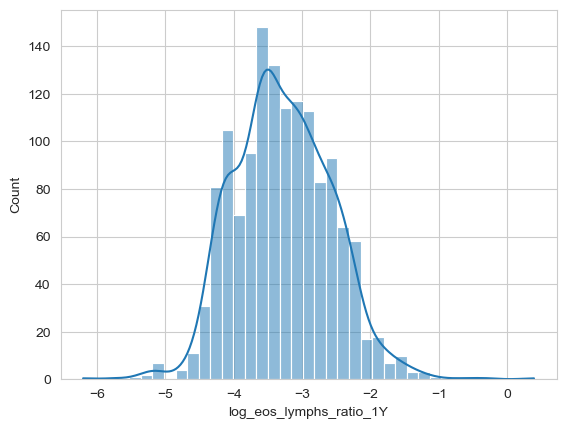

In [69]:
sns.histplot(data=subjects,x='log_eos_lymphs_ratio_1Y',kde=True)

<Axes: xlabel='log_eos_neuts_ratio_1Y', ylabel='Count'>

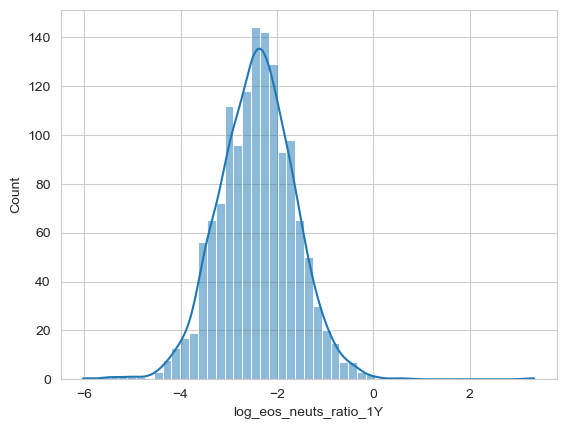

In [70]:
sns.histplot(data=subjects,x='log_eos_neuts_ratio_1Y',kde=True)

<Axes: xlabel='log_eos_lymphs_ratio_5Y', ylabel='Count'>

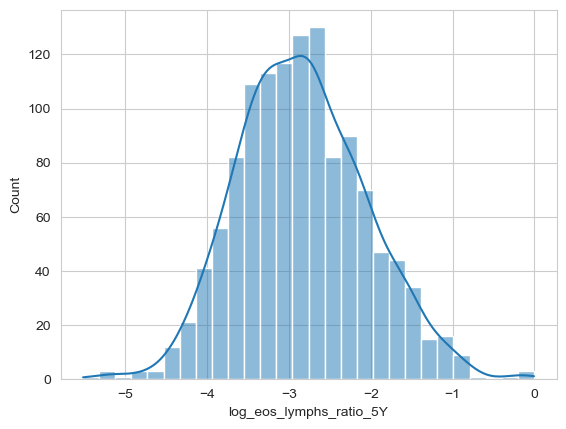

In [71]:
sns.histplot(data=subjects,x='log_eos_lymphs_ratio_5Y',kde=True)

<Axes: xlabel='log_eos_neuts_ratio_5Y', ylabel='Count'>

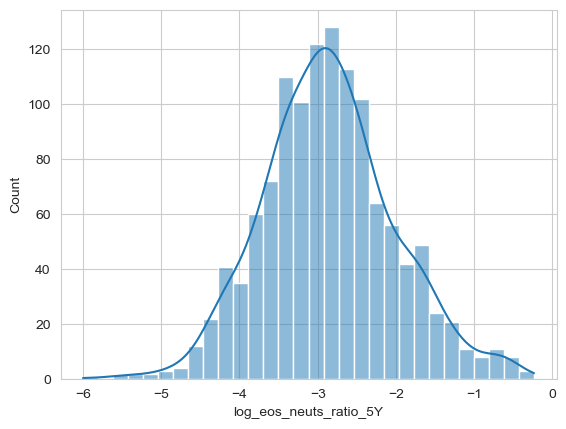

In [72]:
sns.histplot(data=subjects,x='log_eos_neuts_ratio_5Y',kde=True)

In [73]:
child_absolute_cbc = child_absolute_cbc[['subject_id','log_eos_lymphs_ratio_1Y','log_basos_lymphs_ratio_1Y','log_eos_monos_ratio_1Y','log_neuts_lymphs_ratio_1Y','log_eos_neuts_ratio_1Y','log_monos_lymphs_ratio_1Y','log_eos_lymphs_ratio_birth','log_basos_lymphs_ratio_birth','log_eos_monos_ratio_birth','log_neuts_lymphs_ratio_birth','log_eos_neuts_ratio_birth','log_monos_lymphs_ratio_birth']]

In [74]:
child_absolute_cbc.to_csv("data/wbc_ratios_birth_and_1y.csv",index=False)

In [75]:
child_blood_cbc = pd.read_csv("data/child-blood-cbc-variables-wide.csv")
child_blood_cbc_metadata = pd.read_csv("metadata/child-blood-cbc-metadata.csv")
xref_to_short_name={}
for index, row in child_blood_cbc_metadata.iterrows():
    suffix=""  

    if row['visit'] == 'Birth':
        suffix="birth"

    if row['visit'] == 'Prenatal 18 weeks':
        suffix="prenatal"

    if row['visit'] == '18 Months':
        suffix="18m"

    if row['visit'] == '3 Months':
        suffix="3m"

    if row['visit'] == '6 Months':
        suffix="6m"
    

    if row['visit'] == '1 Year':
        suffix="1Y"

    if row['visit'] == '2 Years':
        suffix="2Y"
    if row['visit'] == '2.5 Years':
        suffix="30m"
    if row['visit'] == '3 Years':
        suffix="3Y"
    if row['visit'] == '5 Years':
        suffix="5Y"

    
    xref_to_short_name[row['base_variable_name']]=row['short_name']+"_"+suffix
child_blood_cbc.rename(columns=xref_to_short_name,inplace=True)

subjects = pd.merge(subjects,child_blood_cbc,how="left",on="subject_id")

# log transform cell types
subjects['log_eos_relative_5Y'] = np.log(subjects['eos_relative_5Y']+1)
subjects['log_eos_relative_1Y'] = np.log(subjects['eos_relative_1Y']+1)

subjects['log_monos_relative_5Y'] = np.log(subjects['monos_relative_5Y']+1)
subjects['log_monos_relative_1Y'] = np.log(subjects['monos_relative_1Y']+1)

subjects['log_basos_relative_5Y'] = np.log(subjects['basos_relative_5Y']+1)
subjects['log_basos_relative_1Y'] = np.log(subjects['basos_relative_1Y']+1)

subjects['log_neuts_relative_5Y'] = np.log(subjects['neuts_relative_5Y']+1)
subjects['log_neuts_relative_1Y'] = np.log(subjects['neuts_relative_1Y']+1)

subjects['log_lymphs_relative_5Y'] = np.log(subjects['lymphs_relative_5Y']+1)
subjects['log_lymphs_relative_1Y'] = np.log(subjects['lymphs_relative_1Y']+1)



In [76]:
exposures=['weekly_chem_hand_cleaner_use_mother_prenatal','high_dehp_dust_3m']

celltypes = ['log_eos_lymphs_ratio_1Y','log_basos_lymphs_ratio_1Y','log_eos_monos_ratio_1Y','log_eos_monos_ratio_5Y','log_eos_lymphs_ratio_5Y','log_basos_lymphs_ratio_5Y','log_neuts_lymphs_ratio_1Y','log_neuts_lymphs_ratio_5Y','log_eos_neuts_ratio_1Y','log_eos_neuts_ratio_5Y','log_monos_lymphs_ratio_1Y','log_monos_lymphs_ratio_5Y']
covariates = ['site_toronto', 'site_vancouver', 'site_edmonton','is_male','winter_birth','spring_birth','summer_birth','autumn_birth','older_children_in_home_3m']

In [77]:
columns = ['subject_id'] + exposures + celltypes + covariates


df = subjects[columns]



In [78]:
master_odds_ratio_table = pd.DataFrame(columns=['visit','exposure','celltype','mean relative abundance (no exposure)','n (no exposure group)','mean relative abundance (exposure)','n (exposure group)','U1','p','q','reject_null'])


odds_ratio_table = pd.DataFrame(columns=['visit','exposure','celltype','mean relative abundance (no exposure)','n (no exposure group)','mean relative abundance (exposure)','n (exposure group)','U1','p'])


for exposure in exposures:
    print("Processing exposure: "+exposure)
    for celltype in celltypes:
    
      
            if 1:
                
                exposure_and_celltype_list = [exposure,celltype]
            

                X = df[exposure_and_celltype_list]
                X.dropna(inplace=True)
                X_grouped = X.groupby(exposure).mean()[[celltype]]

                positive_exposures = X[X[exposure]==1]
                positive_exposures = positive_exposures[celltype].tolist()
               # print(len(positive_exposures))
                # Get mean of the positive exposure group
                positive_exposure_cytokine_series = pd.Series(positive_exposures)
                mean_cytokine_positive_exposures = positive_exposure_cytokine_series.sum()/len(positive_exposures)
                #print(mean_cytokine_positive_exposures)



                negative_exposures = X[X[exposure]==0]
                negative_exposures = negative_exposures[celltype].tolist()
                #print(len(negative_exposures))
                # Get mean of the positive exposure group
                negative_exposure_cytokine_series = pd.Series(negative_exposures)
                mean_cytokine_negative_exposures = negative_exposure_cytokine_series.sum()/len(negative_exposures)
               

                p=1
                
                if 1:

                    if "1Y" in celltype:
                         visit = "1 Year"
                    if "5Y" in celltype:
                         visit = '5 Years'

                    # Mann-Whitney non-parametric test for differences in mean
                    U1, p = mannwhitneyu(positive_exposures, negative_exposures)
                    rowdata = {}
                    rowdata['visit'] = visit
                    rowdata['exposure'] = exposure
                    rowdata['celltype'] = celltype
                    rowdata['mean relative abundance (no exposure)'] = round(mean_cytokine_negative_exposures,3)
                    rowdata['n (no exposure group)'] = len(negative_exposures)
                    rowdata['mean relative abundance (exposure)'] = +round(mean_cytokine_positive_exposures,3)
                    rowdata['n (exposure group)'] = len(positive_exposures)
                    rowdata['U1'] =  U1
                    rowdata['p'] = p
                    odds_ratio_table.loc[len(odds_ratio_table)] = rowdata
                
                
                
                
                #print([U1,p])
                if p<0.05:
                    print(exposure+"\t"+celltype+"\t"+str(round(mean_cytokine_negative_exposures,3))+"\t"+str(len(negative_exposures))+"\t"+str(round(mean_cytokine_positive_exposures,3))+"\t"+str(len(positive_exposures))+"\t"+str(U1)+"\t"+str(p))



            if 0:
                print("Error with "+celltype)

Processing exposure: weekly_chem_hand_cleaner_use_mother_prenatal
Processing exposure: high_dehp_dust_3m
high_dehp_dust_3m	log_eos_lymphs_ratio_1Y	-3.306	253	-3.039	85	12944.5	0.004928440263803314
high_dehp_dust_3m	log_eos_lymphs_ratio_5Y	-2.82	247	-2.578	85	12355.0	0.014978447034019366
high_dehp_dust_3m	log_eos_neuts_ratio_1Y	-2.471	253	-2.19	85	12619.0	0.01666311879107633
high_dehp_dust_3m	log_eos_neuts_ratio_5Y	-2.864	247	-2.634	85	12034.0	0.04418360691902647


# Multiple testing correction for 1- and 5-year analyses

In [79]:
import statsmodels.stats.multitest
# Remove any nan p-values
frames=[]
for exposure in exposures:
    

    for visit in ['1 Year','5 Years']:

        temp = odds_ratio_table[(odds_ratio_table['exposure']==exposure) & (odds_ratio_table['visit']==visit)]
        temp = temp[temp['p'].notna()]

        if len(temp)>0:


            # Perform multiple testing to get q value
            reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['p'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
            # Adds the q-value (correct p-value) and Pass/Fail to the data frame
            temp['q']=q

            #print(temp['q'])

            temp['reject_null']=reject
            temp = temp[temp['reject_null']==True]
            frames.append(temp)
            temp.to_csv("celltype-counts-and-means/cell-type-mean-differences_"+current_date+"-"+visit+"_"+exposure+".csv",index=False)

            for index, row in temp.iterrows():
                if row['reject_null']==True:

                    rowdata = {}
                    rowdata['visit'] = '5 Years'
                    rowdata['exposure'] = exposure
                    rowdata['celltype'] = row['celltype']
                    rowdata['mean relative abundance (no exposure)'] = row['mean relative abundance (no exposure)']
                    rowdata['n (no exposure group)'] = row['n (no exposure group)']
                    rowdata['mean relative abundance (exposure)'] = row['mean relative abundance (exposure)']
                    rowdata['n (exposure group)'] = row['n (exposure group)']
                    rowdata['U1'] =  row['U1']
                    rowdata['p'] =  row['p']
                    rowdata['q'] = row['q']
                    rowdata['reject_null']=row['reject_null']

                    master_odds_ratio_table.loc[len(master_odds_ratio_table)]=rowdata

                    print(row['exposure']+"\t"+row['celltype']+"\t"+str(row['mean relative abundance (no exposure)'])+"\t"+str(row['mean relative abundance (exposure)'])+"\t"+str(row['p'])+str(row['q']))

high_dehp_dust_3m	log_eos_lymphs_ratio_1Y	-3.306	-3.039	0.0049284402638033140.029570641582819888
high_dehp_dust_3m	log_eos_neuts_ratio_1Y	-2.471	-2.19	0.016663118791076330.049989356373228995


In [80]:
odds_ratio_table_corrected_for_fdr = pd.concat(frames)
odds_ratio_table_corrected_for_fdr[odds_ratio_table_corrected_for_fdr['reject_null']==True]

,visit,exposure,celltype,mean relative abundance (no exposure),n (no exposure group),mean relative abundance (exposure),n (exposure group),U1,p,q,reject_null
12,1 Year,high_dehp_dust_3m,log_eos_lymphs_ratio_1Y,-3.306,253,-3.039,85,12944.5,0.004928,0.029571,True
20,1 Year,high_dehp_dust_3m,log_eos_neuts_ratio_1Y,-2.471,253,-2.190,85,12619.0,0.016663,0.049989,True


# Supplementary figure 12a - log ELR (1y) for house dust DEHP levels in upper quartile 

In [81]:
#celltypes_eos = ['log_eos_lymphs_ratio_1Y','log_eos_relative_1Y','log_eos_lymphs_ratio_5Y','log_eos_relative_5Y']

celltypes_eos = ['log_eos_lymphs_ratio_1Y']

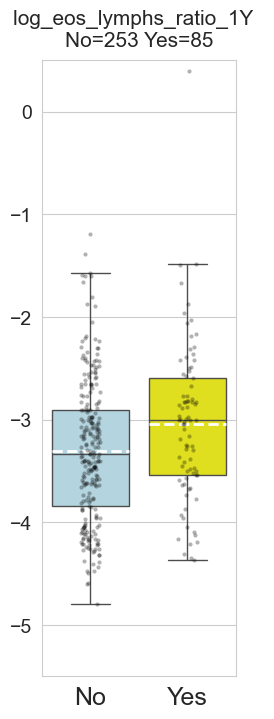

In [82]:

sns.set_style("whitegrid")



# Set up the figure
plt.figure(figsize=(2.5, 8))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Define a custom grey color palette
palette = ["lightblue", "yellow"]


# Iterate through each cytokine and create subplots
for i, celltype in enumerate(celltypes_eos, start=1):


    # Filter the dataframe
    tmp = subjects[~subjects[celltype].isna()]
    tmp = tmp[~tmp['high_dehp_dust_3m'].isna()]

    n_0 = len(tmp[tmp['high_dehp_dust_3m']==0])
    n_1 = len(tmp[tmp['high_dehp_dust_3m']==1])

    #plt.subplot(5, 4, i)
    ax = sns.boxplot(data=tmp, y=celltype, x="high_dehp_dust_3m", showfliers=False,
                     palette=palette, showmeans=True, meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
    sns.stripplot(data=tmp, y=celltype, x="high_dehp_dust_3m", color="black", alpha=0.3, size=3)
    
    # Set x-axis labels
    plt.xticks([0, 1], ['No', 'Yes'])
    
    # Set x-axis title and increase font size
    ax.set_xlabel("", fontsize=18)
    
    # Set y-axis title and increase font size
    ax.set_ylabel("", fontsize=18)
    
    # Increase y-axis tick label font size
    ax.tick_params(axis='y', labelsize=14)
    
    # Increase x-axis tick label font size
    ax.tick_params(axis='x', labelsize=18)
    
    # Add subtitle for the celltype
    plt.title(celltype + "  \nNo="+str(n_0)+ " Yes="+str(n_1), fontsize=15, pad=10)

    # Add 10% to the y-axis limits to allow space for text above the error bars
    #ylim = ax.get_ylim()
    #ax.set_ylim(ylim[0], ylim[1] * 1.1)

    #x1, x2 = 0, 1   # Positions for the bracket
    #y, h, col = tmp[celltype].max() + 0.2, 0.05, 'k'   # Y position and height of the bracket
    #plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)   # Draw the bracket
    #plt.text((x1+x2)*.5, y+h, "*", ha='center', va='bottom', color=col, fontsize=14)   # Add asterisk

# Adjust the layout
#plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
# Add a main title
#plt.suptitle("Cytokine Levels at 1 Year by Infant Given Cereal Before 6 Months", fontsize=16, y=1.01)
plt.ylim(-5.5,0.5)
plt.show()


In [83]:

celltypes_eos = ['log_eos_lymphs_ratio_5Y']

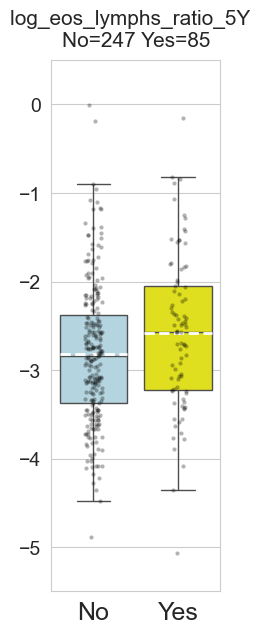

In [84]:

sns.set_style("whitegrid")



# Set up the figure
plt.figure(figsize=(12, 40))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Define a custom grey color palette
palette = ["lightblue", "yellow"]


# Iterate through each cytokine and create subplots
for i, celltype in enumerate(celltypes_eos, start=1):


    # Filter the dataframe
    tmp = subjects[~subjects[celltype].isna()]
    tmp = tmp[~tmp['high_dehp_dust_3m'].isna()]

    n_0 = len(tmp[tmp['high_dehp_dust_3m']==0])
    n_1 = len(tmp[tmp['high_dehp_dust_3m']==1])

    plt.subplot(5, 4, i)
    ax = sns.boxplot(data=tmp, y=celltype, x="high_dehp_dust_3m", showfliers=False,
                     palette=palette, showmeans=True, meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
    sns.stripplot(data=tmp, y=celltype, x="high_dehp_dust_3m", color="black", alpha=0.3, size=3)
    
    # Set x-axis labels
    plt.xticks([0, 1], ['No', 'Yes'])
    
    # Set x-axis title and increase font size
    ax.set_xlabel("", fontsize=18)
    
    # Set y-axis title and increase font size
    ax.set_ylabel("", fontsize=18)
    
    # Increase y-axis tick label font size
    ax.tick_params(axis='y', labelsize=14)
    
    # Increase x-axis tick label font size
    ax.tick_params(axis='x', labelsize=18)
    
    # Add subtitle for the celltype
    plt.title(celltype + "  \nNo="+str(n_0)+ " Yes="+str(n_1), fontsize=15, pad=10)

    # Add 10% to the y-axis limits to allow space for text above the error bars
    #ylim = ax.get_ylim()
    #ax.set_ylim(ylim[0], ylim[1] * 1.1)

    #x1, x2 = 0, 1   # Positions for the bracket
    #y, h, col = tmp[celltype].max() + 0.2, 0.05, 'k'   # Y position and height of the bracket
    #plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)   # Draw the bracket
    #plt.text((x1+x2)*.5, y+h, "*", ha='center', va='bottom', color=col, fontsize=14)   # Add asterisk

    # Adjust the layout
    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.5)
    # Add a main title
    #plt.suptitle("Cytokine Levels at 1 Year by Infant Given Cereal Before 6 Months", fontsize=16, y=1.01)
    plt.ylim(-5.5,0.5)
plt.show()


# Supplementary Figure 12a - log ENR (1y) for house dust DEHP levels in upper quartile

In [85]:

celltypes_eos = ['log_eos_neuts_ratio_1Y']

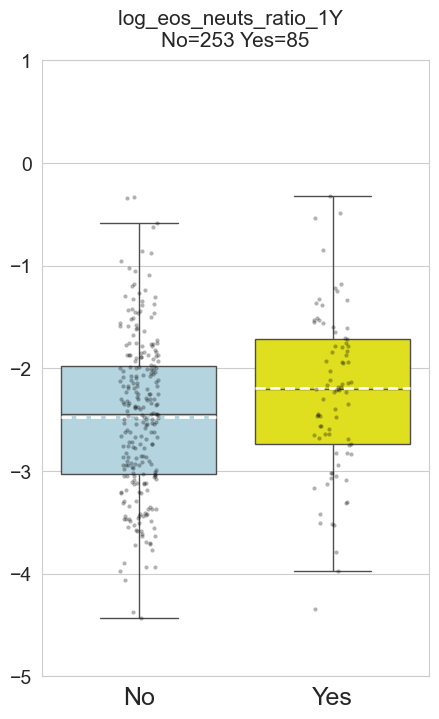

In [86]:

sns.set_style("whitegrid")



# Set up the figure
plt.figure(figsize=(5, 8))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Define a custom grey color palette
palette = ["lightblue", "yellow"]


# Iterate through each cytokine and create subplots
for i, celltype in enumerate(celltypes_eos, start=1):


    # Filter the dataframe
    tmp = subjects[~subjects[celltype].isna()]
    tmp = tmp[~tmp['high_dehp_dust_3m'].isna()]

    n_0 = len(tmp[tmp['high_dehp_dust_3m']==0])
    n_1 = len(tmp[tmp['high_dehp_dust_3m']==1])

    #plt.subplot(5, 4, i)
    ax = sns.boxplot(data=tmp, y=celltype, x="high_dehp_dust_3m", showfliers=False,
                     palette=palette, showmeans=True, meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
    sns.stripplot(data=tmp, y=celltype, x="high_dehp_dust_3m", color="black", alpha=0.3, size=3)
    
    # Set x-axis labels
    plt.xticks([0, 1], ['No', 'Yes'])
    
    # Set x-axis title and increase font size
    ax.set_xlabel("", fontsize=18)
    
    # Set y-axis title and increase font size
    ax.set_ylabel("", fontsize=18)
    
    # Increase y-axis tick label font size
    ax.tick_params(axis='y', labelsize=14)
    
    # Increase x-axis tick label font size
    ax.tick_params(axis='x', labelsize=18)
    
    # Add subtitle for the celltype
    plt.title(celltype + "  \nNo="+str(n_0)+ " Yes="+str(n_1), fontsize=15, pad=10)

    # Add 10% to the y-axis limits to allow space for text above the error bars
    #ylim = ax.get_ylim()
    #ax.set_ylim(ylim[0], ylim[1] * 1.1)

    #x1, x2 = 0, 1   # Positions for the bracket
    #y, h, col = tmp[celltype].max() + 0.2, 0.05, 'k'   # Y position and height of the bracket
    #plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)   # Draw the bracket
    #plt.text((x1+x2)*.5, y+h, "*", ha='center', va='bottom', color=col, fontsize=14)   # Add asterisk

# Adjust the layout
#plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
# Add a main title
#plt.suptitle("Cytokine Levels at 1 Year by Infant Given Cereal Before 6 Months", fontsize=16, y=1.01)
plt.ylim(-5,1)
plt.show()


# Supplementary figures 9b and 9d - Differences in log ELR (9b) and log ENR (9d) associated with weekly oven cleaner use (prenatal) - unadjusted

In [87]:

celltypes_eos = ['log_eos_lymphs_ratio_1Y','log_eos_neuts_ratio_1Y']

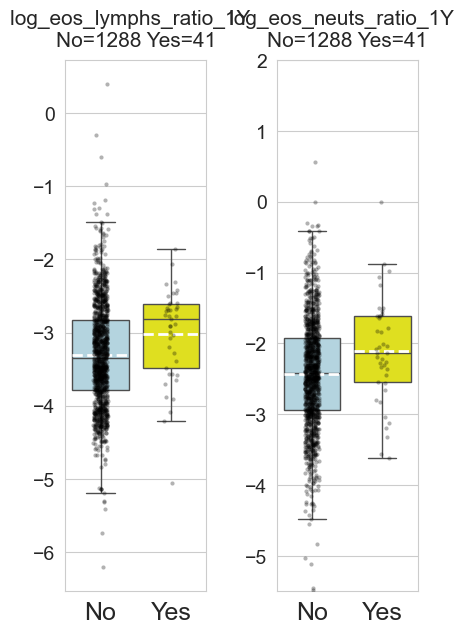

In [88]:

sns.set_style("whitegrid")



# Set up the figure
plt.figure(figsize=(10, 40))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Define a custom grey color palette
palette = ["lightblue", "yellow"]


# Iterate through each cytokine and create subplots
for i, celltype in enumerate(celltypes_eos, start=1):


    # Filter the dataframe
    tmp = subjects[~subjects[celltype].isna()]
    tmp = tmp[~tmp['weekly_oven_cleaner_use_prenatal'].isna()]

    n_0 = len(tmp[tmp['weekly_oven_cleaner_use_prenatal']==0])
    n_1 = len(tmp[tmp['weekly_oven_cleaner_use_prenatal']==1])

    plt.subplot(5, 4, i)
    ax = sns.boxplot(data=tmp, y=celltype, x="weekly_oven_cleaner_use_prenatal", showfliers=False,
                     palette=palette, showmeans=True, meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
    sns.stripplot(data=tmp, y=celltype, x="weekly_oven_cleaner_use_prenatal", color="black", alpha=0.3, size=3)
    
    # Set x-axis labels
    plt.xticks([0, 1], ['No', 'Yes'])
    
    # Set x-axis title and increase font size
    ax.set_xlabel("", fontsize=18)
    
    # Set y-axis title and increase font size
    ax.set_ylabel("", fontsize=18)
    
    # Increase y-axis tick label font size
    ax.tick_params(axis='y', labelsize=14)
    
    # Increase x-axis tick label font size
    ax.tick_params(axis='x', labelsize=18)
    
    # Add subtitle for the celltype
    plt.title(celltype + "  \nNo="+str(n_0)+ " Yes="+str(n_1), fontsize=15, pad=10)

    # Add 10% to the y-axis limits to allow space for text above the error bars
    #ylim = ax.get_ylim()
    #ax.set_ylim(ylim[0], ylim[1] * 1.1)

    #x1, x2 = 0, 1   # Positions for the bracket
    #y, h, col = tmp[celltype].max() + 0.2, 0.05, 'k'   # Y position and height of the bracket
    #plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)   # Draw the bracket
    #plt.text((x1+x2)*.5, y+h, "*", ha='center', va='bottom', color=col, fontsize=14)   # Add asterisk

# Adjust the layout
#plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
# Add a main title
#plt.suptitle("Cytokine Levels at 1 Year by Infant Given Cereal Before 6 Months", fontsize=16, y=1.01)
plt.ylim(-5.5,2)
plt.show()


# Supplementary figure 12b: Associations between Dust DEHP in upper quartile, covariates and log ELR ratio (1y)

                               OLS Regression Results                              
Dep. Variable:     log_eos_lymphs_ratio_1Y   R-squared:                       0.081
Model:                                 OLS   Adj. R-squared:                  0.043
Method:                      Least Squares   F-statistic:                     2.129
Date:                     Sun, 26 Apr 2026   Prob (F-statistic):             0.0153
Time:                             21:27:45   Log-Likelihood:                -313.63
No. Observations:                      304   AIC:                             653.3
Df Residuals:                          291   BIC:                             701.6
Df Model:                               12                                         
Covariance Type:                 nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

Text(0.5, 38.72222222222221, 'Adjusted beta coefficient and 95% confidence intervals')

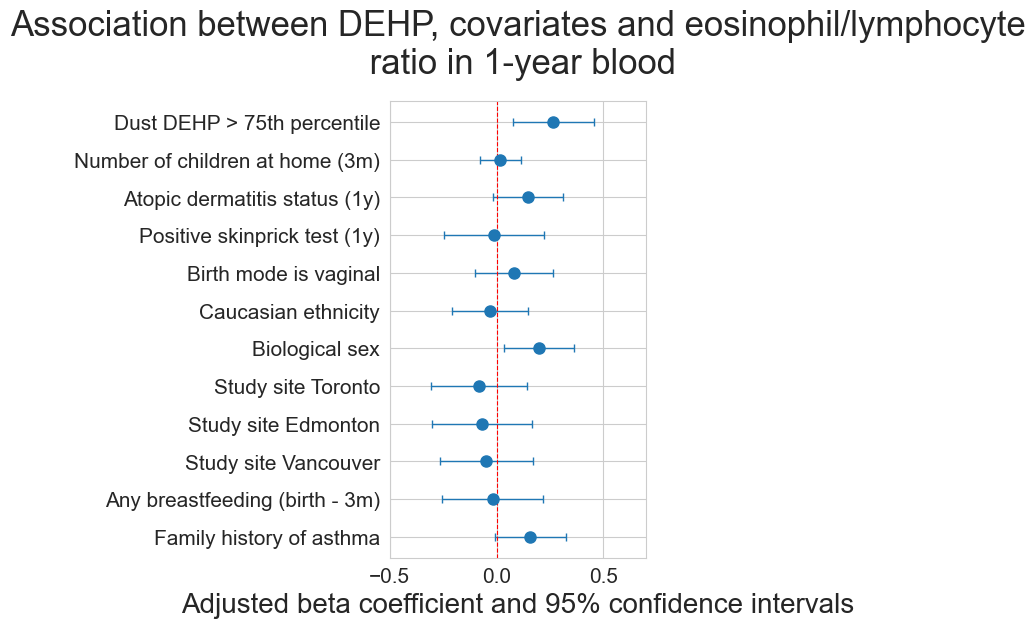

In [89]:
beta_coefficients_table = pd.DataFrame(columns=['outcome','exposure','num_exposed','total participants','beta','lower CI', 'upper CI','p-value','significant'])

tmp = subjects[~subjects['log_eos_lymphs_ratio_1Y'].isna()]
tmp = tmp[~tmp['high_dehp_dust_3m'].isna()]

# Fit  model with interaction term
model = sm.formula.ols('log_eos_lymphs_ratio_1Y ~ high_dehp_dust_3m + num_children_at_home_3m + atopic_dermatitis_status_1y  + atopy_binary_1y  +    vaginal_birth + is_caucasian + is_male + site_toronto + site_edmonton + site_vancouver + BF_3m + family_asthma_history', data=subjects).fit()

# Print model summary
print(model.summary())

significant_effect_row = {}
significant_effect_row['outcome']="log_eos_lymphs_ratio_1Y"
significant_effect_row['num_exposed']=np.nan
significant_effect_row['total participants']=len(subjects)
vars = model.params
for index, value in vars.items():
    if index !="Intercept":
       print(index)
       significant_effect_row['exposure']=index
       # beta coefficient      
       significant_effect_row['beta'] = round(value,4)

       pvals = model.pvalues
       for index2, value in pvals.items():
           if index2 ==index:
               significant_effect_row['p-value']=round(value,3)

       intervals = model.conf_int(alpha = .05 )
       for index3, row in intervals.iterrows():
           if index3 == index:
                # for odds
                significant_effect_row['lower CI']=round(row[0],3)
                significant_effect_row['upper CI']=round(row[1],3)

       if significant_effect_row['p-value']<0.05 and significant_effect_row['p-value']>0.01:
            significant_effect_row['significant']="*"
       elif significant_effect_row['p-value']<0.01:
            significant_effect_row['significant']="**"
       else:
            significant_effect_row['significant']=""         
                                
       beta_coefficients_table.loc[len(beta_coefficients_table)] = significant_effect_row

beta_coefficients_table = beta_coefficients_table.replace('site_vancouver','Study site Vancouver')
beta_coefficients_table = beta_coefficients_table.replace('site_edmonton','Study site Edmonton')
beta_coefficients_table = beta_coefficients_table.replace('site_winnipeg','Study site Winnipeg')
beta_coefficients_table = beta_coefficients_table.replace('site_toronto','Study site Toronto')
beta_coefficients_table = beta_coefficients_table.replace('BF_3m','Any breastfeeding (birth - 3m)')
beta_coefficients_table = beta_coefficients_table.replace('atopic_dermatitis_status_1y','Atopic dermatitis status (1y)')
beta_coefficients_table = beta_coefficients_table.replace('num_children_at_home_3m','Number of children at home (3m)')
beta_coefficients_table = beta_coefficients_table.replace('high_dehp_dust_3m:vaginal_birth','High dust DEHP : vaginal birth=yes')
beta_coefficients_table = beta_coefficients_table.replace('atopy_binary_1y','Positive skinprick test (1y)')
beta_coefficients_table = beta_coefficients_table.replace('log_dehp_bc_rec_dust_3m','log DEHP levels')
beta_coefficients_table = beta_coefficients_table.replace('high_dehp_dust_3m','Dust DEHP > 75th percentile')
beta_coefficients_table = beta_coefficients_table.replace('family_asthma_history','Family history of asthma')
beta_coefficients_table = beta_coefficients_table.replace('is_caucasian','Caucasian ethnicity')
beta_coefficients_table = beta_coefficients_table.replace('vaginal_birth','Birth mode is vaginal')
beta_coefficients_table = beta_coefficients_table.replace('is_male','Biological sex')

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(5, 6))
plt.title("Association between DEHP, covariates and eosinophil/lymphocyte\n ratio in 1-year blood", fontsize=25, pad=20)
#plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
#ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')


for idx, row in beta_coefficients_table.iloc[::-1].iterrows():
    ci = [[row['beta'] - row[::-1]['lower CI']], [row['upper CI'] - row['beta']]]
    if row['p-value'] < 0.05:
        label = str(row['beta'])        
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
    else:
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")


plt.axvline(x=0, linewidth=0.8, linestyle='--', color='red')

plt.xlim(-0.5,0.7)
plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel('Adjusted beta coefficient and 95% confidence intervals', fontsize=20)

# Supplementary figure 9c: Associations between weekly prenatal oven cleaner use, eosinophil-lymphocyte ratio (ELR) at 1 year

                               OLS Regression Results                              
Dep. Variable:     log_eos_lymphs_ratio_1Y   R-squared:                       0.030
Model:                                 OLS   Adj. R-squared:                  0.020
Method:                      Least Squares   F-statistic:                     2.959
Date:                     Sun, 26 Apr 2026   Prob (F-statistic):           0.000448
Time:                             21:27:45   Log-Likelihood:                -1228.7
No. Observations:                     1156   AIC:                             2483.
Df Residuals:                         1143   BIC:                             2549.
Df Model:                               12                                         
Covariance Type:                 nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Text(0.5, 38.72222222222221, 'Adjusted beta coefficient and 95% confidence intervals')

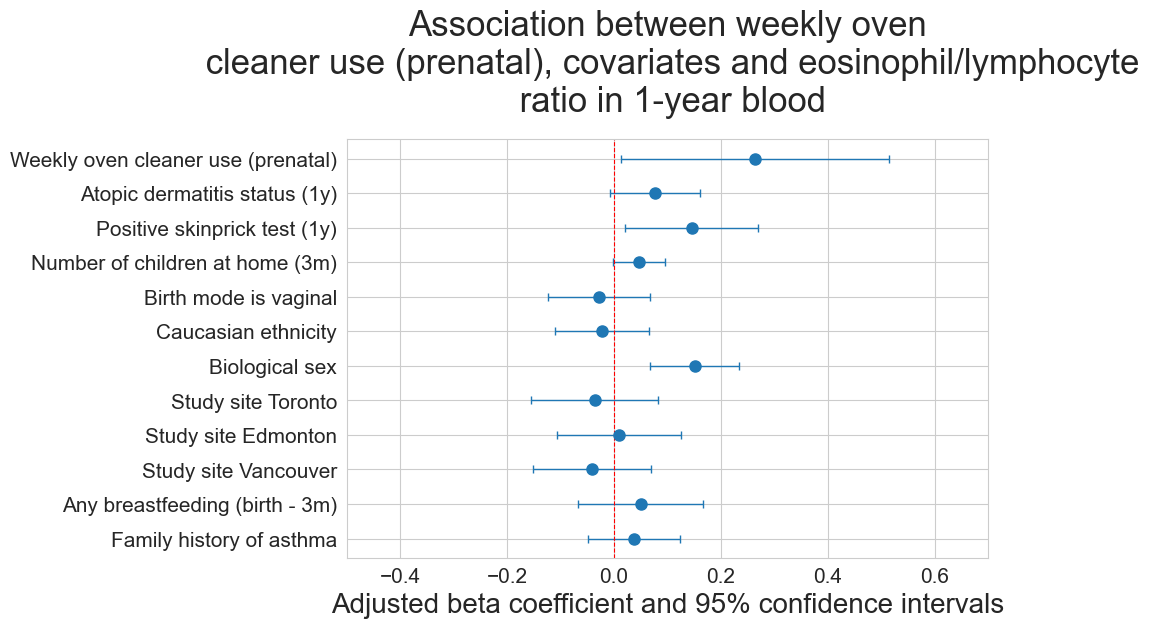

In [90]:
tmp = subjects[~subjects['log_eos_lymphs_ratio_1Y'].isna()]
tmp = tmp[tmp['eos_relative_1Y']!=0]
tmp = tmp[tmp['lymphs_relative_1Y']!=0]
tmp = tmp[tmp['neuts_relative_1Y']!=0]
tmp = tmp[~tmp['weekly_oven_cleaner_use_prenatal'].isna()]
#tmp = tmp[tmp['num_children_at_home_3m']==1]


# Fit  model with interaction term
model = sm.formula.ols('log_eos_lymphs_ratio_1Y ~ weekly_oven_cleaner_use_prenatal + atopic_dermatitis_status_1y + atopy_binary_1y + num_children_at_home_3m +  vaginal_birth + is_caucasian + is_male + site_toronto + site_edmonton + site_vancouver + BF_3m + family_asthma_history', data=tmp).fit()

# Print model summary
print(model.summary())


beta_coefficients_table = pd.DataFrame(columns=['outcome','exposure','num_exposed','total participants','beta','lower CI', 'upper CI','p-value','significant'])


significant_effect_row = {}
significant_effect_row['outcome']="log_eos_lymphs_ratio_1Y"
significant_effect_row['num_exposed']=np.nan
significant_effect_row['total participants']=len(subjects)
vars = model.params
for index, value in vars.items():
    if index !="Intercept":
       print(index)
       significant_effect_row['exposure']=index
       # beta coefficient      
       significant_effect_row['beta'] = round(value,4)

       pvals = model.pvalues
       for index2, value in pvals.items():
           if index2 ==index:
               significant_effect_row['p-value']=round(value,3)

       intervals = model.conf_int(alpha = .05 )
       for index3, row in intervals.iterrows():
           if index3 == index:
                # for odds
                significant_effect_row['lower CI']=round(row[0],3)
                significant_effect_row['upper CI']=round(row[1],3)

       if significant_effect_row['p-value']<0.05 and significant_effect_row['p-value']>0.01:
            significant_effect_row['significant']="*"
       elif significant_effect_row['p-value']<0.01:
            significant_effect_row['significant']="**"
       else:
            significant_effect_row['significant']=""         
                                
       beta_coefficients_table.loc[len(beta_coefficients_table)] = significant_effect_row

beta_coefficients_table = beta_coefficients_table.replace('site_vancouver','Study site Vancouver')
beta_coefficients_table = beta_coefficients_table.replace('site_edmonton','Study site Edmonton')
beta_coefficients_table = beta_coefficients_table.replace('site_winnipeg','Study site Winnipeg')
beta_coefficients_table = beta_coefficients_table.replace('site_toronto','Study site Toronto')
beta_coefficients_table = beta_coefficients_table.replace('BF_3m','Any breastfeeding (birth - 3m)')
beta_coefficients_table = beta_coefficients_table.replace('atopic_dermatitis_status_1y','Atopic dermatitis status (1y)')
beta_coefficients_table = beta_coefficients_table.replace('num_children_at_home_3m','Number of children at home (3m)')
beta_coefficients_table = beta_coefficients_table.replace('weekly_oven_cleaner_use_prenatal','Weekly oven cleaner use (prenatal)')
beta_coefficients_table = beta_coefficients_table.replace('high_dehp_dust_3m','High dust DEHP')
beta_coefficients_table = beta_coefficients_table.replace('family_asthma_history','Family history of asthma')
beta_coefficients_table = beta_coefficients_table.replace('is_caucasian','Caucasian ethnicity')
beta_coefficients_table = beta_coefficients_table.replace('atopy_binary_1y','Positive skinprick test (1y)')
beta_coefficients_table = beta_coefficients_table.replace('vaginal_birth','Birth mode is vaginal')
beta_coefficients_table = beta_coefficients_table.replace('is_male','Biological sex')

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(9, 6))
plt.title("Association between weekly oven\n cleaner use (prenatal), covariates and eosinophil/lymphocyte\n ratio in 1-year blood", fontsize=25, pad=20)
#plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
#ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')


for idx, row in beta_coefficients_table.iloc[::-1].iterrows():
    ci = [[row['beta'] - row[::-1]['lower CI']], [row['upper CI'] - row['beta']]]
    if row['p-value'] < 0.05:
        label = str(row['beta'])        
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
    else:
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")


plt.axvline(x=0, linewidth=0.8, linestyle='--', color='red')

plt.xlim(-0.5,0.7)
plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel('Adjusted beta coefficient and 95% confidence intervals', fontsize=20)

# Supplementary figure 12b: Associations between Dust DEHP in upper quartile, covariates and log ENR ratio (1y)

                              OLS Regression Results                              
Dep. Variable:     log_eos_neuts_ratio_1Y   R-squared:                       0.076
Model:                                OLS   Adj. R-squared:                  0.037
Method:                     Least Squares   F-statistic:                     1.981
Date:                    Sun, 26 Apr 2026   Prob (F-statistic):             0.0258
Time:                            21:27:46   Log-Likelihood:                -361.49
No. Observations:                     304   AIC:                             749.0
Df Residuals:                         291   BIC:                             797.3
Df Model:                              12                                         
Covariance Type:                nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

Text(0.5, 38.72222222222221, 'Adjusted beta coefficient and 95% confidence intervals')

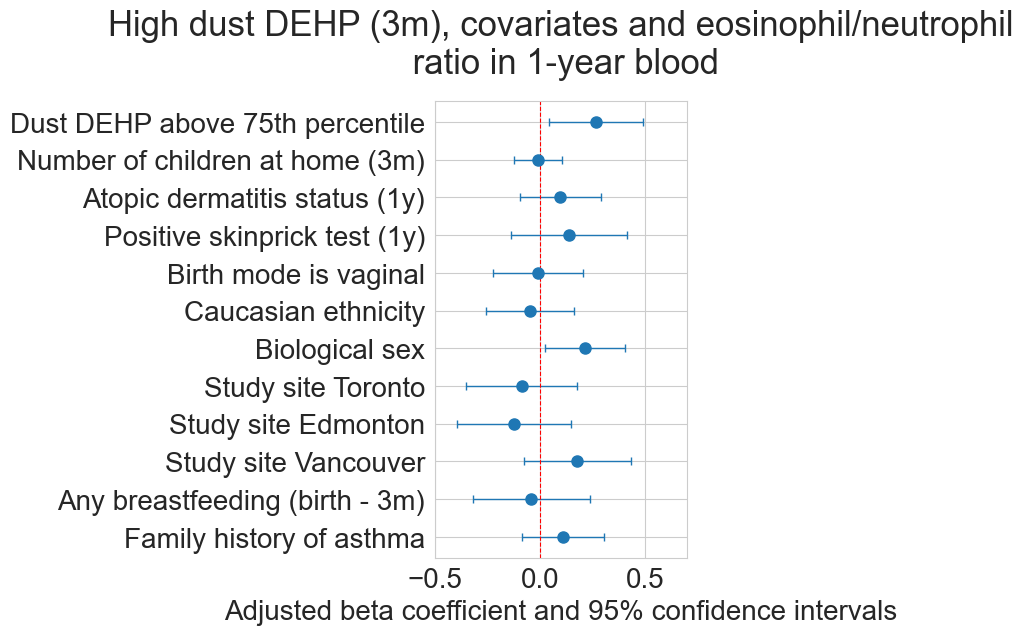

In [91]:
tmp = subjects[~subjects['log_eos_neuts_ratio_1Y'].isna()]
tmp = tmp[~tmp['weekly_oven_cleaner_use_prenatal'].isna()]

# Fit  model with interaction term
model = sm.formula.ols('log_eos_neuts_ratio_1Y ~ high_dehp_dust_3m + num_children_at_home_3m + atopic_dermatitis_status_1y + atopy_binary_1y + vaginal_birth + is_caucasian + is_male + site_toronto + site_edmonton + site_vancouver + BF_3m + family_asthma_history', data=subjects).fit()

# Print model summary
print(model.summary())


beta_coefficients_table = pd.DataFrame(columns=['outcome','exposure','num_exposed','total participants','beta','lower CI', 'upper CI','p-value','significant'])


significant_effect_row = {}
significant_effect_row['outcome']="log_eos_neuts_ratio_1Y"
significant_effect_row['num_exposed']=np.nan
significant_effect_row['total participants']=len(subjects)
vars = model.params
for index, value in vars.items():
    if index !="Intercept":
       print(index)
       significant_effect_row['exposure']=index
       # beta coefficient      
       significant_effect_row['beta'] = round(value,4)

       pvals = model.pvalues
       for index2, value in pvals.items():
           if index2 ==index:
               significant_effect_row['p-value']=round(value,3)

       intervals = model.conf_int(alpha = .05 )
       for index3, row in intervals.iterrows():
           if index3 == index:
                # for odds
                significant_effect_row['lower CI']=round(row[0],3)
                significant_effect_row['upper CI']=round(row[1],3)

       if significant_effect_row['p-value']<0.05 and significant_effect_row['p-value']>0.01:
            significant_effect_row['significant']="*"
       elif significant_effect_row['p-value']<0.01:
            significant_effect_row['significant']="**"
       else:
            significant_effect_row['significant']=""         
                                
       beta_coefficients_table.loc[len(beta_coefficients_table)] = significant_effect_row

beta_coefficients_table = beta_coefficients_table.replace('site_vancouver','Study site Vancouver')
beta_coefficients_table = beta_coefficients_table.replace('site_edmonton','Study site Edmonton')
beta_coefficients_table = beta_coefficients_table.replace('site_winnipeg','Study site Winnipeg')
beta_coefficients_table = beta_coefficients_table.replace('site_toronto','Study site Toronto')
beta_coefficients_table = beta_coefficients_table.replace('atopic_dermatitis_status_1y','Atopic dermatitis status (1y)')
beta_coefficients_table = beta_coefficients_table.replace('num_children_at_home_3m','Number of children at home (3m)')
beta_coefficients_table = beta_coefficients_table.replace('BF_3m','Any breastfeeding (birth - 3m)')
beta_coefficients_table = beta_coefficients_table.replace('weekly_oven_cleaner_use_prenatal','Weekly oven cleaner use (prenatal)')
beta_coefficients_table = beta_coefficients_table.replace('high_dehp_dust_3m','Dust DEHP above 75th percentile')
beta_coefficients_table = beta_coefficients_table.replace('family_asthma_history','Family history of asthma')
beta_coefficients_table = beta_coefficients_table.replace('is_caucasian','Caucasian ethnicity')
beta_coefficients_table = beta_coefficients_table.replace('atopy_binary_1y','Positive skinprick test (1y)')
beta_coefficients_table = beta_coefficients_table.replace('vaginal_birth','Birth mode is vaginal')
beta_coefficients_table = beta_coefficients_table.replace('is_male','Biological sex')

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(5, 6))
plt.title("High dust DEHP (3m), covariates and eosinophil/neutrophil\n ratio in 1-year blood", fontsize=25, pad=20)
#plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
#ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')


for idx, row in beta_coefficients_table.iloc[::-1].iterrows():
    ci = [[row['beta'] - row[::-1]['lower CI']], [row['upper CI'] - row['beta']]]
    if row['p-value'] < 0.05:
        label = str(row['beta'])        
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
    else:
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")


plt.axvline(x=0, linewidth=0.8, linestyle='--', color='red')

plt.xlim(-0.5,0.7)
plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel('Adjusted beta coefficient and 95% confidence intervals', fontsize=20)

# Supplementary figure 9e: Associations between weekly prenatal oven cleaner, covariates and log ENR ratio (1y)

                              OLS Regression Results                              
Dep. Variable:     log_eos_neuts_ratio_1Y   R-squared:                       0.038
Model:                                OLS   Adj. R-squared:                  0.028
Method:                     Least Squares   F-statistic:                     3.809
Date:                    Sun, 26 Apr 2026   Prob (F-statistic):           1.03e-05
Time:                            21:27:46   Log-Likelihood:                -1362.4
No. Observations:                    1157   AIC:                             2751.
Df Residuals:                        1144   BIC:                             2816.
Df Model:                              12                                         
Covariance Type:                nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

Text(0.5, 38.72222222222221, 'Adjusted beta coefficient and 95% confidence intervals')

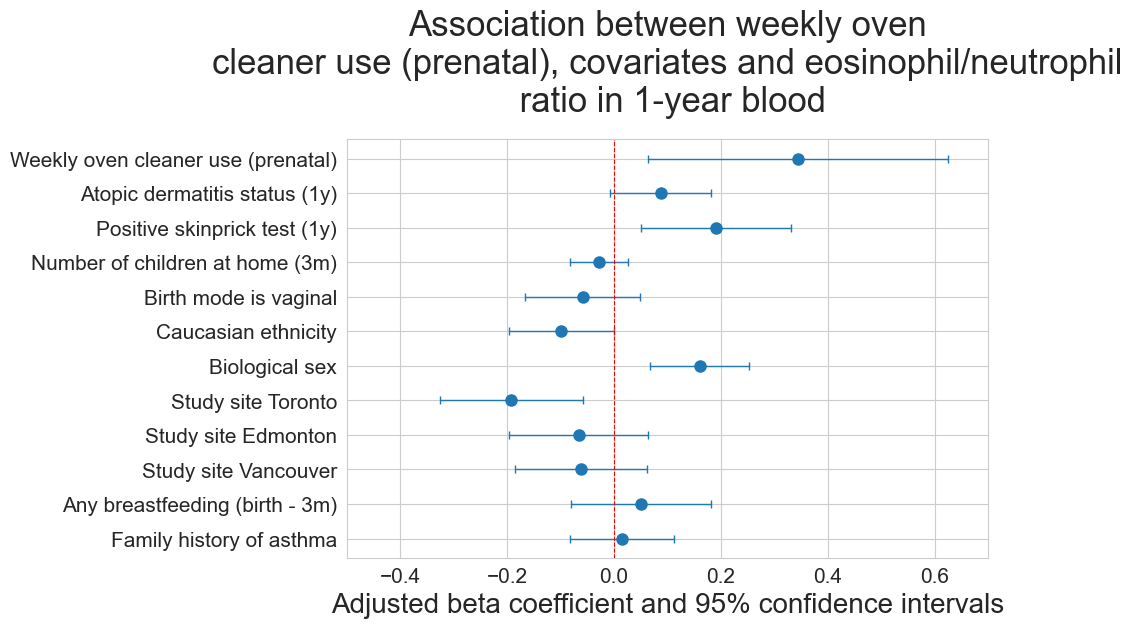

In [92]:
tmp = subjects[~subjects['log_eos_neuts_ratio_1Y'].isna()]
tmp = tmp[~tmp['weekly_oven_cleaner_use_prenatal'].isna()]

# Fit  model with interaction term
model = sm.formula.ols('log_eos_neuts_ratio_1Y ~ weekly_oven_cleaner_use_prenatal + atopic_dermatitis_status_1y + atopy_binary_1y  + num_children_at_home_3m  +  vaginal_birth + is_caucasian + is_male + site_toronto + site_edmonton + site_vancouver + BF_3m + family_asthma_history', data=subjects).fit()

# Print model summary
print(model.summary())


beta_coefficients_table = pd.DataFrame(columns=['outcome','exposure','num_exposed','total participants','beta','lower CI', 'upper CI','p-value','significant'])


significant_effect_row = {}
significant_effect_row['outcome']="log_eos_lymphs_ratio_1Y"
significant_effect_row['num_exposed']=np.nan
significant_effect_row['total participants']=len(subjects)
vars = model.params
for index, value in vars.items():
    if index !="Intercept":
       print(index)
       significant_effect_row['exposure']=index
       # beta coefficient      
       significant_effect_row['beta'] = round(value,4)

       pvals = model.pvalues
       for index2, value in pvals.items():
           if index2 ==index:
               significant_effect_row['p-value']=round(value,3)

       intervals = model.conf_int(alpha = .05 )
       for index3, row in intervals.iterrows():
           if index3 == index:
                # for odds
                significant_effect_row['lower CI']=round(row[0],3)
                significant_effect_row['upper CI']=round(row[1],3)

       if significant_effect_row['p-value']<0.05 and significant_effect_row['p-value']>0.01:
            significant_effect_row['significant']="*"
       elif significant_effect_row['p-value']<0.01:
            significant_effect_row['significant']="**"
       else:
            significant_effect_row['significant']=""         
                                
       beta_coefficients_table.loc[len(beta_coefficients_table)] = significant_effect_row

beta_coefficients_table = beta_coefficients_table.replace('site_vancouver','Study site Vancouver')
beta_coefficients_table = beta_coefficients_table.replace('site_edmonton','Study site Edmonton')
beta_coefficients_table = beta_coefficients_table.replace('site_winnipeg','Study site Winnipeg')
beta_coefficients_table = beta_coefficients_table.replace('site_toronto','Study site Toronto')
beta_coefficients_table = beta_coefficients_table.replace('BF_3m','Any breastfeeding (birth - 3m)')
beta_coefficients_table = beta_coefficients_table.replace('atopic_dermatitis_status_1y','Atopic dermatitis status (1y)')
beta_coefficients_table = beta_coefficients_table.replace('num_children_at_home_3m','Number of children at home (3m)')
beta_coefficients_table = beta_coefficients_table.replace('weekly_oven_cleaner_use_prenatal','Weekly oven cleaner use (prenatal)')
beta_coefficients_table = beta_coefficients_table.replace('high_dehp_dust_3m','High dust DEHP')
beta_coefficients_table = beta_coefficients_table.replace('family_asthma_history','Family history of asthma')
beta_coefficients_table = beta_coefficients_table.replace('is_caucasian','Caucasian ethnicity')
beta_coefficients_table = beta_coefficients_table.replace('atopy_binary_1y','Positive skinprick test (1y)')
beta_coefficients_table = beta_coefficients_table.replace('vaginal_birth','Birth mode is vaginal')
beta_coefficients_table = beta_coefficients_table.replace('is_male','Biological sex')

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(9, 6))
plt.title("Association between weekly oven\ncleaner use (prenatal), covariates and eosinophil/neutrophil\n ratio in 1-year blood", fontsize=25, pad=20)
#plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
#ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')


for idx, row in beta_coefficients_table.iloc[::-1].iterrows():
    ci = [[row['beta'] - row[::-1]['lower CI']], [row['upper CI'] - row['beta']]]
    if row['p-value'] < 0.05:
        label = str(row['beta'])        
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
    else:
        plt.errorbar(x=[row['beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=3, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")


plt.axvline(x=0, linewidth=0.8, linestyle='--', color='red')

plt.xlim(-0.5,0.7)
plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel('Adjusted beta coefficient and 95% confidence intervals', fontsize=20)